In [52]:
!pip install seaborn
!pip install pydot graphviz

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

df = pd.read_csv('/content/Final_IMDB_Dataset.csv')

# View the first 10 rows of the dataset
print("First 10 rows of the dataset :\n")
print(df.head(10))

First 10 rows of the dataset :

      tconst                          primaryTitle  \
0  tt0000574           The Story of the Kelly Gang   
1  tt0000591                      The Prodigal Son   
2  tt0000679        The Fairylogue and Radio-Plays   
3  tt0001184               Don Juan de Serrallonga   
4  tt0001285                     The Life of Moses   
5  tt0001498               The Battle of Trafalgar   
6  tt0001592                  In the Prime of Life   
7  tt0001790  Les Misérables, Part 1: Jean Valjean   
8  tt0001812                           Oedipus Rex   
9  tt0001892                        Den sorte drøm   

                             originalTitle  year  runtimeMinutes  \
0              The Story of the Kelly Gang  1906              70   
1                        L'enfant prodigue  1907              90   
2           The Fairylogue and Radio-Plays  1908             120   
3                  Don Juan de Serrallonga  1910              58   
4                        The Life

In [54]:
# Number of rows and columns
print("Shape of the Dataset :")
print(df.shape)

# Dataset summary
print("\nDataset Summary :\n")
df.info()

Shape of the Dataset :
(214926, 17)

Dataset Summary :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214926 entries, 0 to 214925
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tconst          214926 non-null  object 
 1   primaryTitle    214926 non-null  object 
 2   originalTitle   214926 non-null  object 
 3   year            214926 non-null  int64  
 4   runtimeMinutes  214926 non-null  int64  
 5   genres          214926 non-null  object 
 6   genre1          214926 non-null  object 
 7   genre2          118486 non-null  object 
 8   genre3          55893 non-null   object 
 9   averageRating   214926 non-null  float64
 10  numVotes        214926 non-null  int64  
 11  directors       213964 non-null  object 
 12  directorName    213961 non-null  object 
 13  writers         201548 non-null  object 
 14  writerNames     201547 non-null  object 
 15  topActorIDs     214926 non-null  object 
 16  

In [55]:
# No target column
target_col = None

# Classification based on data types
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Columns that are lists stored as strings.
multilabel_cols = ['genres', 'directorName', 'actorNames', 'writerNames']

for col in multilabel_cols:
    if col in categorical_cols:
        categorical_cols.remove(col)

# Final classified columns
print(f"Target Column : {target_col}")
print(f"Numerical Columns ({len(numerical_cols)}) : {numerical_cols}")
print(f"Categorical Columns ({len(categorical_cols)}) : {categorical_cols}")
print(f"Multi-label Columns ({len(multilabel_cols)}) : {multilabel_cols}")

Target Column : None
Numerical Columns (4) : ['year', 'runtimeMinutes', 'averageRating', 'numVotes']
Categorical Columns (9) : ['tconst', 'primaryTitle', 'originalTitle', 'genre1', 'genre2', 'genre3', 'directors', 'writers', 'topActorIDs']
Multi-label Columns (4) : ['genres', 'directorName', 'actorNames', 'writerNames']


In [56]:
# Missing Values in each column
missing_values = df.isnull().sum()
print("Missing values per column :\n")
print(missing_values)


print("\nPercentage of Missing values per column :\n")
print((missing_values / len(df)) * 100)

Missing values per column :

tconst                 0
primaryTitle           0
originalTitle          0
year                   0
runtimeMinutes         0
genres                 0
genre1                 0
genre2             96440
genre3            159033
averageRating          0
numVotes               0
directors            962
directorName         965
writers            13378
writerNames        13379
topActorIDs            0
actorNames             0
dtype: int64

Percentage of Missing values per column :

tconst             0.000000
primaryTitle       0.000000
originalTitle      0.000000
year               0.000000
runtimeMinutes     0.000000
genres             0.000000
genre1             0.000000
genre2            44.871258
genre3            73.994305
averageRating      0.000000
numVotes           0.000000
directors          0.447596
directorName       0.448992
writers            6.224468
writerNames        6.224933
topActorIDs        0.000000
actorNames         0.000000
dtype: float6

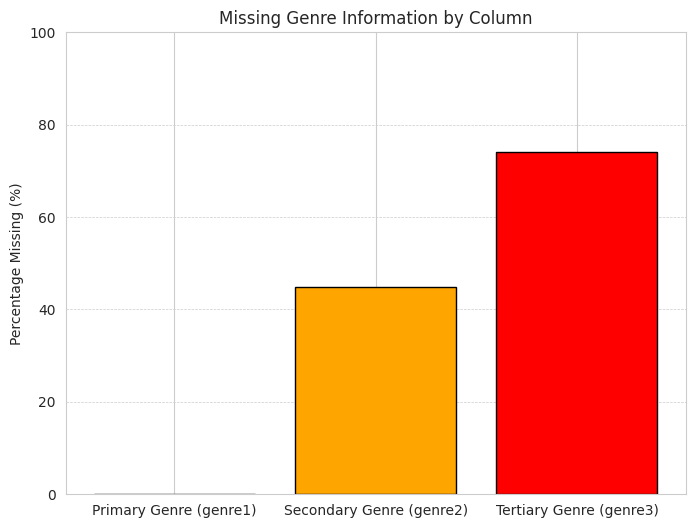

In [57]:
# Count missing values
missing_counts = [
    df['genre1'].isna().sum(),
    df['genre2'].isna().sum(),
    df['genre3'].isna().sum()
]

# Total movies
total_movies = len(df)

# Percentage missing
missing_percent = [ (m / total_movies) * 100 for m in missing_counts ]

# Genre labels
genres = ['Primary Genre (genre1)', 'Secondary Genre (genre2)', 'Tertiary Genre (genre3)']

# Plot
plt.figure(figsize=(8, 6))
plt.bar(genres, missing_percent, color=['green', 'orange', 'red'], edgecolor='black')
plt.ylabel('Percentage Missing (%)')
plt.title('Missing Genre Information by Column')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.show()

In [58]:
# Fill missing secondary genres with 'None'
df['genre2'] = df['genre2'].fillna('None')
df['genre3'] = df['genre3'].fillna('None')

# Check genre distribution
print(df['genre1'].value_counts().head(10))
print('\n', df['genre2'].value_counts().head(10))
print('\n', df['genre3'].value_counts().head(10))

genre1
Drama          69035
Comedy         53737
Action         25232
Crime          11834
Horror          9865
Adventure       9811
Documentary     9291
Biography       4625
Adult           3539
Thriller        3512
Name: count, dtype: int64

 genre2
None         96440
Drama        35089
Romance      15204
Crime         8243
Thriller      7921
Comedy        7281
Horror        6002
Adventure     5513
Family        4913
Mystery       4696
Name: count, dtype: int64

 genre3
None        159033
Romance      10616
Thriller      9710
Drama         7547
Mystery       3730
Fantasy       2671
Family        2661
Sci-Fi        2563
War           2212
Horror        2169
Name: count, dtype: int64


In [59]:
# Drop rows where 'directorName' is missing
df = df[~df['directorName'].isnull()]

# Fill missing writers and writerNames with 'Unknown'
df['writers'] = df['writers'].fillna('Unknown')
df['writerNames'] = df['writerNames'].fillna('Unknown')

# Re-check for Missing Values
print("Missing values :\n")
print(df.isnull().sum())

Missing values :

tconst            0
primaryTitle      0
originalTitle     0
year              0
runtimeMinutes    0
genres            0
genre1            0
genre2            0
genre3            0
averageRating     0
numVotes          0
directors         0
directorName      0
writers           0
writerNames       0
topActorIDs       0
actorNames        0
dtype: int64


In [60]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows : {duplicates}")

# Check for duplicate tconst entries (MovieIDs)
duplicate_tconst = df['tconst'].duplicated().sum()
print(f"Number of duplicate tconst entries : {duplicate_tconst}")

Number of duplicate rows : 0
Number of duplicate tconst entries : 0


In [61]:
import ast

# Convert list-like strings to actual lists
for col in multilabel_cols:
    if col in df.columns:
        df[col] = df[col].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith('[') else x
        )

# Ensure 'startYear' and 'runtimeMinutes' are numeric
df['startYear'] = pd.to_numeric(df['year'], errors='coerce')
df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')

# Output shape
print("Shape of pre-processed dataset :")
print(df.shape)

# Output sample
print("\nFirst 10 rows of the pre-processed dataset :\n")
print(df.head(10))

Shape of pre-processed dataset :
(213961, 18)

First 10 rows of the pre-processed dataset :

      tconst                          primaryTitle  \
0  tt0000574           The Story of the Kelly Gang   
1  tt0000591                      The Prodigal Son   
2  tt0000679        The Fairylogue and Radio-Plays   
3  tt0001184               Don Juan de Serrallonga   
4  tt0001285                     The Life of Moses   
5  tt0001498               The Battle of Trafalgar   
6  tt0001592                  In the Prime of Life   
7  tt0001790  Les Misérables, Part 1: Jean Valjean   
8  tt0001812                           Oedipus Rex   
9  tt0001892                        Den sorte drøm   

                             originalTitle  year  runtimeMinutes  \
0              The Story of the Kelly Gang  1906              70   
1                        L'enfant prodigue  1907              90   
2           The Fairylogue and Radio-Plays  1908             120   
3                  Don Juan de Serrallon

In [62]:
from IPython.display import display, HTML

min_votes = 1000
top_movies = df[df['numVotes'] >= min_votes].sort_values(by='averageRating', ascending=False).head(20)

# Display the Table
display(HTML("<h3 style='text-align: center;'> 🎬 Top 20 Movies by Average Rating </h3><br>"))
top_movies_display = top_movies[['primaryTitle', 'originalTitle', 'year', 'genres', 'averageRating', 'numVotes']]
display(top_movies_display)

,primaryTitle,originalTitle,year,genres,averageRating,numVotes
148619,Oru Canadian Diary,Oru Canadian Diary,2021,Thriller,10.0,4440
128350,Hulchul,Hulchul,2020,Drama,9.5,1194
146549,Kapata Nataka Sutradhari,Kapata Nataka Sutradhari,2021,Thriller,9.5,2023
143511,Trikona,Trikona,2022,"Mystery,Thriller",9.5,1041
148690,Nayeem Diaries,Nayeem Diaries,2021,Action,9.4,1086
142680,Fish and Puddle,Fish and Puddle,2021,"Drama,Family",9.4,2150
200586,Love in Kilnerry,Love in Kilnerry,2019,Comedy,9.4,4620
148746,Bullet Satyam,Bullet Satyam,2021,Action,9.4,1021
210932,Charlie Boy,Charlie Boy,2021,"Comedy,Drama,Romance",9.4,1891
213044,Ananthu v/s Nusrath,Ananthu V/S Nusrath,2018,"Comedy,Drama,Family",9.3,1059


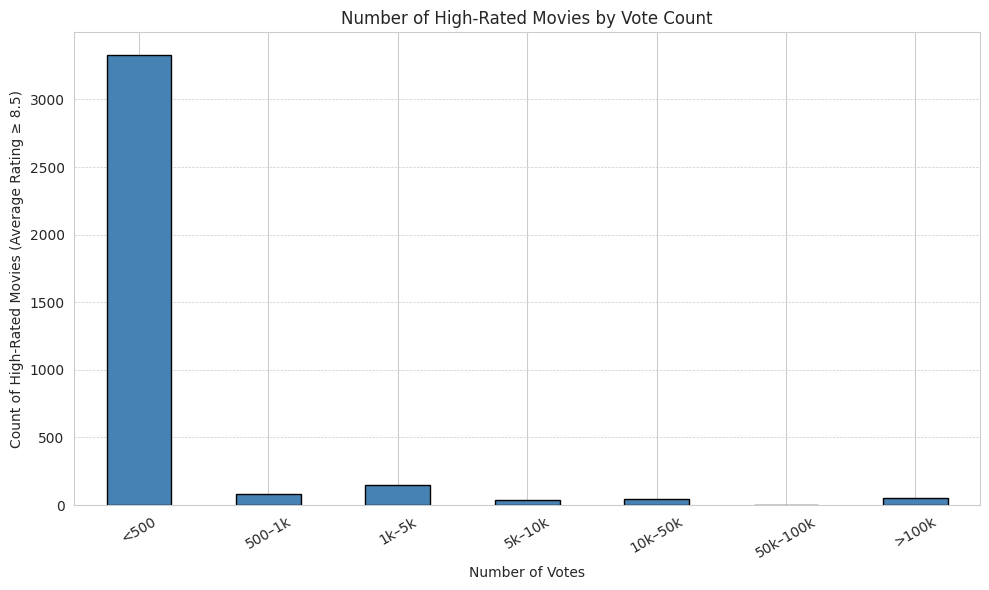

In [63]:
# Define high rating threshold
df['highRated'] = np.where(df['averageRating'] >= 8.5, 'High Rated', 'Normal')

# Create vote bins
bins = [0, 500, 1000, 5000, 10000, 50000, 100000, df['numVotes'].max()]
labels = ['<500', '500–1k', '1k–5k', '5k–10k', '10k–50k', '50k–100k', '>100k']

df['vote_bin'] = pd.cut(df['numVotes'], bins=bins, labels=labels, right=False)

# Count high-rated movies per vote bin
counts = df[df['highRated'] == 'High Rated']['vote_bin'].value_counts().sort_index()

# Plot
plt.figure(figsize=(10, 6))
counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of High-Rated Movies by Vote Count')
plt.xlabel('Number of Votes')
plt.ylabel('Count of High-Rated Movies (Average Rating ≥ 8.5)')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [64]:
# Set the vote threshold
m = df['numVotes'].quantile(0.90)  # Top 10% most voted movies
C = df['averageRating'].mean()     # Mean average rating across all movies

print("Weighted Rating (WR) Calculation :")
print(f"Global Mean Rating (C)     : {C:.2f}")
print(f"Minimum Votes Required (m) : {m:.0f}\n")

# Filter movies that meet the vote threshold
qualified_movies = df[df['numVotes'] >= m].copy()

# Compute Weighted Rating
qualified_movies['Weighted Rating'] = (
    (qualified_movies['numVotes'] / (qualified_movies['numVotes'] + m)) * qualified_movies['averageRating']
    + (m / (qualified_movies['numVotes'] + m)) * C
)

# Round WR for presentation
qualified_movies['Weighted Rating'] = qualified_movies['Weighted Rating'].round(2)

# Sort and select top 20 movies
top_wr_movies = qualified_movies.sort_values(by='Weighted Rating', ascending=False).head(20)

# Prepare for display
final_wr_table = top_wr_movies[[
    'primaryTitle', 'originalTitle', 'year', 'genres', 'averageRating', 'numVotes', 'Weighted Rating'
]].rename(columns={
    'primaryTitle': 'Title',
    'originalTitle': 'Original Title',
    'year': 'Year',
    'genres': 'Genres',
    'averageRating': 'Average Rating',
    'numVotes': 'Number of Votes'
})

# Format genres for better readability
final_wr_table['Genres'] = final_wr_table['Genres'].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)

# Styled display table
styled_wr_table = final_wr_table.style\
    .set_properties(**{'text-align': 'left'})\
    .set_table_styles([dict(selector='th', props=[('text-align', 'left')])])\
    .set_caption("🎬 Top 20 Movies by Weighted Rating")\
    .hide(axis='index')\
    .format({
        'Average Rating': '{:.2f}',
        'Weighted Rating': '{:.2f}',
        'Number of Votes': '{:,}'
    })

display(styled_wr_table)

Weighted Rating (WR) Calculation :
Global Mean Rating (C)     : 5.98
Minimum Votes Required (m) : 2549



Title,Original Title,Year,Genres,Average Rating,Number of Votes,Weighted Rating
The Shawshank Redemption,The Shawshank Redemption,1994,Drama,9.30,"2,578,898",9.30
The Godfather,The Godfather,1972,"Crime,Drama",9.20,"1,775,537",9.20
The Chaos Class,Hababam Sinifi,1975,"Comedy,Drama",9.30,"40,045",9.10
The Dark Knight,The Dark Knight,2008,"Action,Crime,Drama",9.00,"2,547,569",9.00
The Lord of the Rings: The Return of the King,The Lord of the Rings: The Return of the King,2003,"Action,Adventure,Drama",9.00,"1,773,177",9.00
Schindler's List,Schindler's List,1993,"Biography,Drama,History",9.00,"1,313,248",8.99
12 Angry Men,12 Angry Men,1957,"Crime,Drama",9.00,"761,677",8.99
The Godfather: Part II,The Godfather: Part II,1974,"Crime,Drama",9.00,"1,227,619",8.99
K.G.F: Chapter 2,K.G.F: Chapter 2,2022,"Action,Crime,Drama",9.00,"79,699",8.91
Pulp Fiction,Pulp Fiction,1994,"Crime,Drama",8.90,"1,978,878",8.90


In [65]:
from IPython.display import display

# Explode the 'directorName' column to ensure one row per director per movie
df_directors = df.explode('directorName')

# Group by director and calculate average rating and number of movies directed
director_stats = df_directors.groupby('directorName')['averageRating'].agg(['mean', 'count'])

# Filter out directors with fewer than 10 movies
director_stats = director_stats[director_stats['count'] >= 10]

# Sort directors by average rating in descending order and select the top 20
top_directors_by_rating = director_stats.sort_values(by='mean', ascending=False).head(20)

# Reset index and rename columns for clarity
top_directors_by_rating = top_directors_by_rating.reset_index()
top_directors_by_rating.columns = ['Director', 'Average Rating', 'Movie Count']
top_directors_by_rating['Average Rating'] = top_directors_by_rating['Average Rating'].round(2)

# Get top 3 movies for each director based on average rating
top_director_names = top_directors_by_rating['Director'].tolist()
df_top_directors = df_directors[df_directors['directorName'].isin(top_director_names)]

top_movies_per_director = (
    df_top_directors
    .sort_values(['directorName', 'averageRating'], ascending=[True, False])
    .groupby('directorName')['primaryTitle']
    .apply(lambda titles: ', '.join(titles.head(3)))  # top 3 movies
    .reset_index(name='Top 3 Movies')
)

# Merge movie titles with director stats
final_director_table = top_directors_by_rating.merge(
    top_movies_per_director, left_on='Director', right_on='directorName'
).drop(columns=['directorName'])

# Display final Table
styled_table = final_director_table[['Director', 'Average Rating', 'Movie Count', 'Top 3 Movies']].style\
    .set_properties(**{'text-align': 'left'})\
    .set_table_styles([dict(selector='th', props=[('text-align', 'left')])])\
    .set_caption("🎥 Top 20 Directors by Average Rating")\
    .hide(axis='index')\
    .format({'Average Rating': "{:.2f}"})

display(styled_table)

Director,Average Rating,Movie Count,Top 3 Movies
Christopher Nolan,8.15,11,"The Dark Knight, Inception, Interstellar"
Alonso O. Lara,8.14,15,"En mis propias manos, La Sombra, Frente Al Enemigo"
S.R. Puttana Kanagal,8.03,15,"Karulinakare, Malammana Pavada, Nagara Haavu"
Pauli Janhunen Calderón,8.02,12,"Departure with the Dead, The Reflection of Kripto, Clank: Red Mosaic"
Morshedul Islam,8.01,10,"Dipu Number 2, Dukhai, Duratta"
Hayao Miyazaki,8.00,12,"Spirited Away, Princess Mononoke, Conan the Future Boy: The Big Giant Robot's Resurrection"
Tofig Taghizade,7.99,11,"Asl dost, Qizil qaz, Köpäk"
Kadiri Venkata Reddy,7.93,10,"Mayabazar, Pathala Bhairavi, Gunasundari Katha"
Satyajit Ray,7.89,31,"The Kingdom of Diamonds, The Adventures of Goopy and Bagha, The World of Apu"
Vijay,7.89,11,"Na Ninna Mareyalare, Mayura, Sanadhi Appanna"


In [66]:
from IPython.display import display

# Explode the 'writerNames' column
df_writers = df.explode('writerNames')

# Group by writer and compute mean rating and count of movies
writer_stats = df_writers.groupby('writerNames')['averageRating'].agg(['mean', 'count'])

# Filter writers with at least 10 movies
writer_stats = writer_stats[writer_stats['count'] >= 10]

# Top 20 writers by average rating
top_writers_by_rating = writer_stats.sort_values(by='mean', ascending=False).head(20).reset_index()
top_writers_by_rating.columns = ['Writer', 'Average Rating', 'Movie Count']
top_writers_by_rating['Average Rating'] = top_writers_by_rating['Average Rating'].round(2)

# Get top 3 movies per writer based on average rating
top_writer_names = top_writers_by_rating['Writer'].tolist()
df_top_writers = df_writers[df_writers['writerNames'].isin(top_writer_names)]

top_movies_per_writer = (
    df_top_writers
    .sort_values(['writerNames', 'averageRating'], ascending=[True, False])
    .groupby('writerNames')['primaryTitle']
    .apply(lambda titles: ', '.join(titles.head(3)))
    .reset_index(name='Top 3 Movies')
)

# Merge movie titles with writer stats
final_writer_table = top_writers_by_rating.merge(
    top_movies_per_writer, left_on='Writer', right_on='writerNames'
).drop(columns=['writerNames'])

# Display final Table
styled_writer_table = final_writer_table[['Writer', 'Average Rating', 'Movie Count', 'Top 3 Movies']].style\
    .set_properties(**{'text-align': 'left'})\
    .set_table_styles([dict(selector='th', props=[('text-align', 'left')])])\
    .set_caption("✒️ Top 20 Writers by Average Rating")\
    .hide(axis='index')\
    .format({'Average Rating': "{:.2f}"})

display(styled_writer_table)

Writer,Average Rating,Movie Count,Top 3 Movies
"M.D. Sundar, Chi Udayashankar",7.92,11,"Keralida Simha, Ravichandra, Shankar Guru"
Bratya Mormarevi,7.76,10,"Taralezhite se razhdat bez bodli, S detza na more, Dvoynikat"
Sergey A.,7.70,26,"Travel from Moscow to St. Petersburg on the ship Nikolai Karamzin, Crimean vacations, Barcelona - Madrid"
Charles Chaplin,7.67,10,"Modern Times, The Great Dictator, The Kid"
"Kôgo Noda, Yasujirô Ozu",7.66,10,"Tokyo Story, Early Summer, Tokyo Twilight"
Samudrala Raghavacharya,7.66,10,"Sri Krishna Pandaveeyam, Vinayaka Chaviti, Narthanasala"
Chris Marker,7.65,14,"Cuba: Battle of the 10,000,000, Le volcan interdit, Kashima Paradise"
Satyajit Ray,7.63,12,"The Kingdom of Diamonds, Nayak: The Hero, The Stranger"
Mullapudi Venkata Ramana,7.56,16,"Andala Ramudu, Gorantha Deepam, Manavoori Pandavulu"
Ingmar Bergman,7.51,28,"Scenes from a Marriage, The Seventh Seal, Wild Strawberries"


In [67]:
# Explode the 'actorNames' column
df_actors = df.explode('actorNames')

# Group by actor, compute mean rating and movie count
actor_stats = df_actors.groupby('actorNames')['averageRating'].agg(['mean', 'count'])
actor_stats = actor_stats[actor_stats['count'] >= 10]

# Get top 20 actors
top_actors_by_rating = actor_stats.sort_values(by='mean', ascending=False).head(20).reset_index()
top_actors_by_rating.columns = ['Actor', 'Average Rating', 'Movie Count']
top_actors_by_rating['Average Rating'] = top_actors_by_rating['Average Rating'].round(2)

# Get top 3 movies per actor
top_actor_names = top_actors_by_rating['Actor'].tolist()
df_top_actors = df_actors[df_actors['actorNames'].isin(top_actor_names)]

top_movies_per_actor = (
    df_top_actors
    .sort_values(['actorNames', 'averageRating'], ascending=[True, False])
    .groupby('actorNames')['primaryTitle']
    .apply(lambda titles: ', '.join(titles.head(3)))
    .reset_index(name='Top 3 Movies')
)

# Merge movie titles with actor stats
final_actor_table = top_actors_by_rating.merge(
    top_movies_per_actor, left_on='Actor', right_on='actorNames'
).drop(columns=['actorNames'])

# Display final Table
styled_actor_table = final_actor_table[['Actor', 'Average Rating', 'Movie Count', 'Top 3 Movies']].style\
    .set_properties(**{'text-align': 'left'})\
    .set_table_styles([dict(selector='th', props=[('text-align', 'left')])])\
    .set_caption("🎭 Top 20 Actors by Average Rating")\
    .hide(axis='index')\
    .format({'Average Rating': "{:.2f}"})

display(styled_actor_table)

Actor,Average Rating,Movie Count,Top 3 Movies
Luis Huizar,8.46,14,"En mis propias manos, La Sombra, Frente Al Enemigo"
Vianey Huizar,8.44,10,"En mis propias manos, La Sombra, Frente Al Enemigo"
Rajkumar,8.42,50,"Bhoodana, Karulinakare, Malammana Pavada"
T.N. Balakrishna,8.30,23,"Pratidhwani, Annapurna, Jagajyothi Basaveshwara"
K.S. Ashwath,8.24,23,"Bhukailasa, Geetha, Nagara Haavu"
Arathi,8.16,13,"Pratidhwani, Nagara Haavu, Sipayi Ramu"
Emilio Janhunen Calderón,7.96,10,"The Reflection of Kripto, Clank: Red Mosaic, Rinoplasticos: A Warrior's Journey"
Grigore Vasiliu-Birlic,7.89,10,"Titanic Waltz, Doua lozuri, D-ale carnavalului"
Leelavathi,7.86,10,"Sipayi Ramu, Na Ninna Mareyalare, Shivarathri Mahatme"
Charles Chaplin,7.82,12,"City Lights, Modern Times, The Great Dictator"


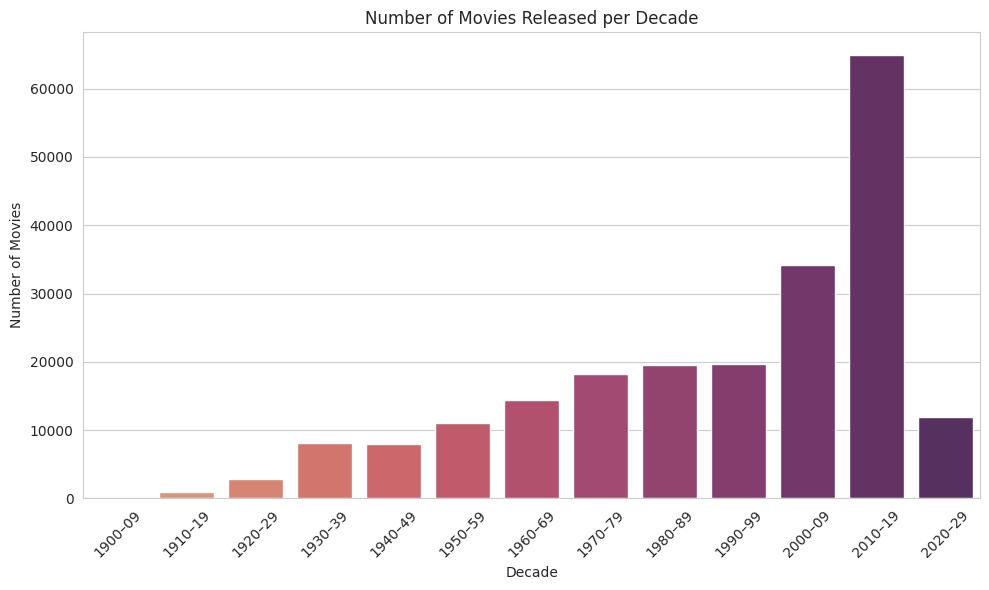

In [68]:
# Create a 'decade' column
df['decade'] = (df['year'] // 10) * 10
df['decade_label'] = df['decade'].astype(str) + '–' + ((df['decade'] % 100 + 9).astype(str).str.zfill(2))

# Count number of movies per decade
decade_counts = df['decade_label'].value_counts().sort_index()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='flare')
plt.title('Number of Movies Released per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

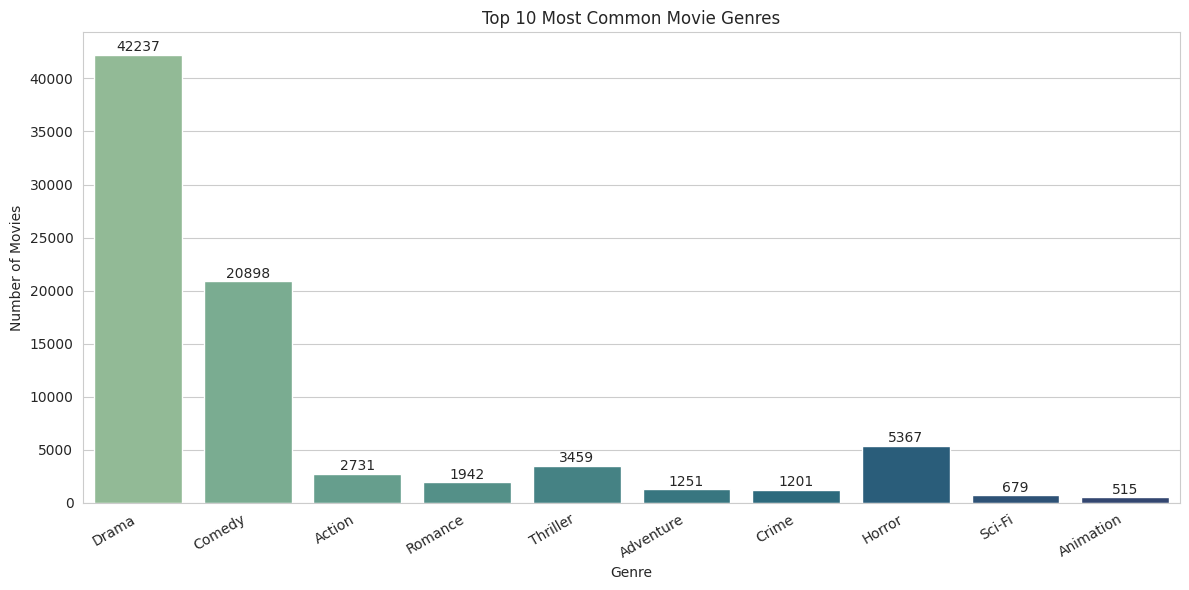

In [69]:
# Define the selected 10 genres
ten_genres = ['Drama', 'Comedy', 'Action', 'Romance', 'Thriller',
                 'Adventure', 'Crime', 'Horror', 'Sci-Fi', 'Animation']

# Explode the genres column to handle multiple genres per movie
df_genres_exploded = df.explode('genres')

# Filter only rows where genre is in the selected 10
df_genres_filtered = df_genres_exploded[df_genres_exploded['genres'].isin(ten_genres)]

# Count the number of occurrences for each genre, keeping your defined order
genre_counts = (
    df_genres_filtered['genres']
    .value_counts()
    .reindex(ten_genres)
    .reset_index()
)

# Rename columns properly
genre_counts.columns = ['Genre', 'Count']

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=genre_counts, x='Genre', y='Count', palette='crest')

# Add count labels
for idx, row in genre_counts.iterrows():
    ax.text(idx, row['Count'] + 50, str(row['Count']), ha='center', va='bottom', fontsize=10)

plt.title('Top 10 Most Common Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

IMDb Rating by Number of Genres :

   genre_count  count  avg_rating   std_dev
0            1  95833    6.016293  1.330905
1            2  62365    5.949056  1.241510
2            3  55763    5.966946  1.251150



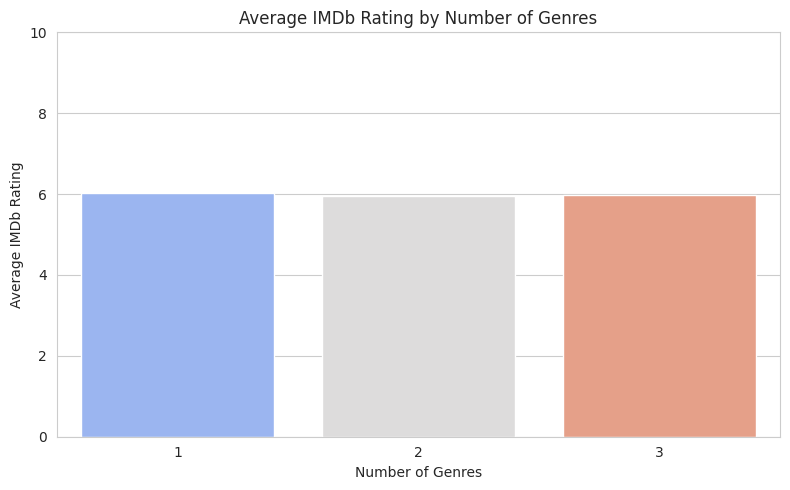

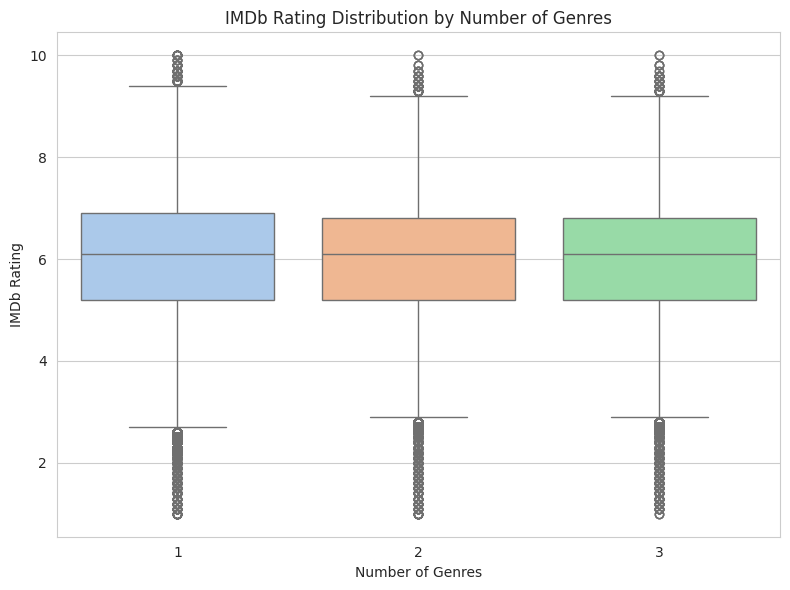

In [70]:
# Replace non-standard nulls with np.nan
missing_values = ['None', 'none', 'null', 'NULL', 'N/A', '', 'NaN', 'nan']
df[['genre1', 'genre2', 'genre3']] = df[['genre1', 'genre2', 'genre3']].replace(missing_values, np.nan)

# Ensure IMDb ratings are numeric
df['averageRating'] = pd.to_numeric(df['averageRating'], errors='coerce')

# Assign genre count
def infer_genre_count(row):
    if pd.notna(row['genre3']):
        return 3
    elif pd.notna(row['genre2']):
        return 2
    elif pd.notna(row['genre1']):
        return 1
    else:
        return 0

df['genre_count'] = df.apply(infer_genre_count, axis=1)

# Filter out rows with 0 genres or missing ratings
df_clean = df[(df['genre_count'] > 0) & (df['averageRating'].notna())]

# Aggregate rating statistics
genre_rating_stats = (
    df_clean.groupby('genre_count')['averageRating']
    .agg(['count', 'mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'avg_rating', 'std': 'std_dev'})
)

# Show table
print("IMDb Rating by Number of Genres :\n")
print(genre_rating_stats)
print()

# Bar Plot of average ratings
plt.figure(figsize=(8, 5))
sns.barplot(data=genre_rating_stats, x='genre_count', y='avg_rating', palette='coolwarm', errorbar='sd')
plt.title('Average IMDb Rating by Number of Genres')
plt.xlabel('Number of Genres')
plt.ylabel('Average IMDb Rating')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

print()

# Boxplot for rating distribution
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='genre_count', y='averageRating', palette='pastel')
plt.title('IMDb Rating Distribution by Number of Genres')
plt.xlabel('Number of Genres')
plt.ylabel('IMDb Rating')
plt.tight_layout()
plt.show()

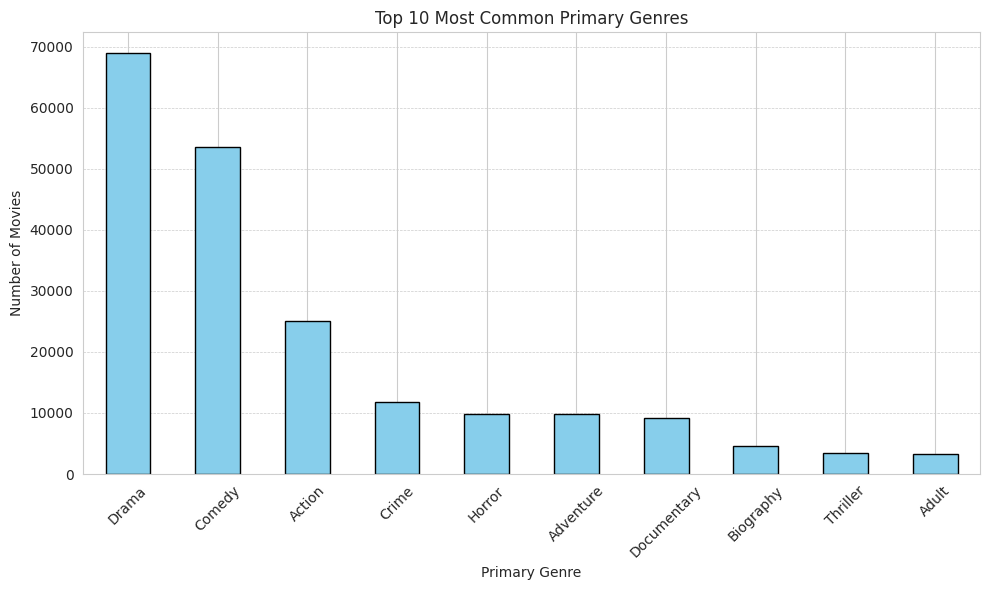

In [71]:
# Count the most frequent primary genres
top_genres = df['genre1'].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 6))
top_genres.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Most Common Primary Genres')
plt.xlabel('Primary Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

Summary Statistics for Runtime (in minutes) :

count    213961.000000
mean         95.657185
std         101.900005
min           2.000000
25%          83.000000
50%          92.000000
75%         104.000000
90%         122.000000
95%         138.000000
99%         168.000000
max       43200.000000
Name: runtimeMinutes, dtype: float64



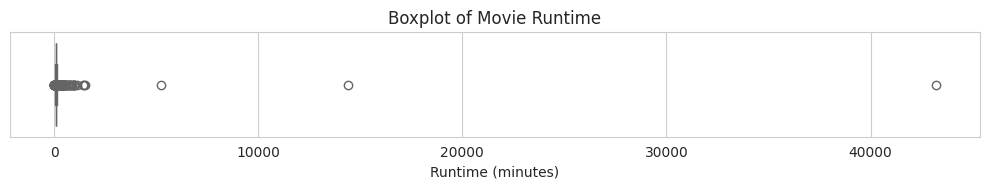


Outlier Threshold Calculation using IQR Method :

IQR (Q3 - Q1) :              21.00
Lower Bound (Q1 - 3.5 X IQR) : 9.50
Upper Bound (Q3 + 3.5 X IQR) : 177.50



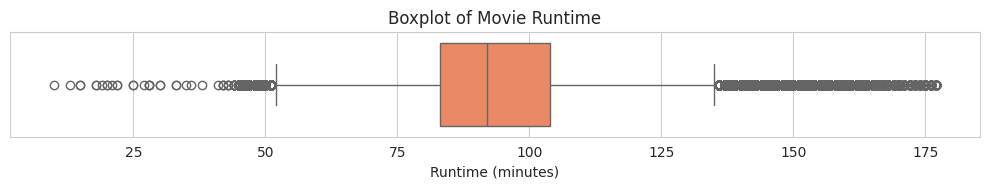

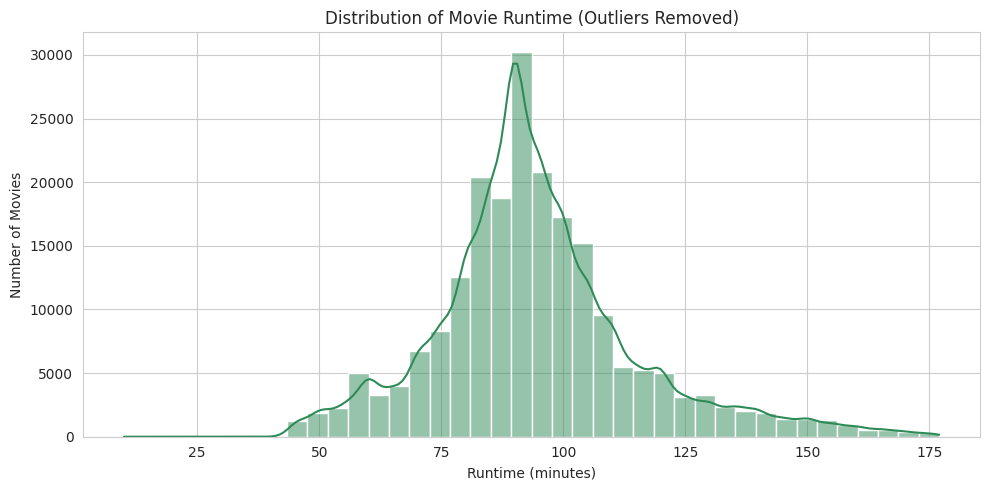

In [72]:
# Outlier Treatment

# Display key descriptive statistics for runtimeMinutes
print("Summary Statistics for Runtime (in minutes) :\n")
print(df['runtimeMinutes'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

print()

# Visualize the runtime distribution using a boxplot to identify outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['runtimeMinutes'], color='coral')
plt.title('Boxplot of Movie Runtime')
plt.xlabel('Runtime (minutes)')
plt.tight_layout()
plt.show()

print()

# Define bounds for outlier removal using IQR method
Q1 = df['runtimeMinutes'].quantile(0.25)
Q3 = df['runtimeMinutes'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3.5 * IQR
upper_bound = Q3 + 3.5 * IQR

# Print calculated statistical values
print("Outlier Threshold Calculation using IQR Method :\n")
print(f"IQR (Q3 - Q1) :              {IQR:.2f}")
print(f"Lower Bound (Q1 - 3.5 X IQR) : {lower_bound:.2f}")
print(f"Upper Bound (Q3 + 3.5 X IQR) : {upper_bound:.2f}")
print()

# Filter out outliers from the runtime column
df_filtered_runtime = df[(df['runtimeMinutes'] >= lower_bound) & (df['runtimeMinutes'] <= upper_bound)]

# Boxplot after removing outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_filtered_runtime['runtimeMinutes'], color='coral')
plt.title('Boxplot of Movie Runtime')
plt.xlabel('Runtime (minutes)')
plt.tight_layout()
plt.show()

print()

# Plot the distribution of runtime after removing outliers
plt.figure(figsize=(10, 5))
sns.histplot(df_filtered_runtime['runtimeMinutes'], bins=40, kde=True, color='seagreen')
plt.title('Distribution of Movie Runtime (Outliers Removed)')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

# Overwrite the original DataFrame to exclude runtime outliers
df = df_filtered_runtime.copy()

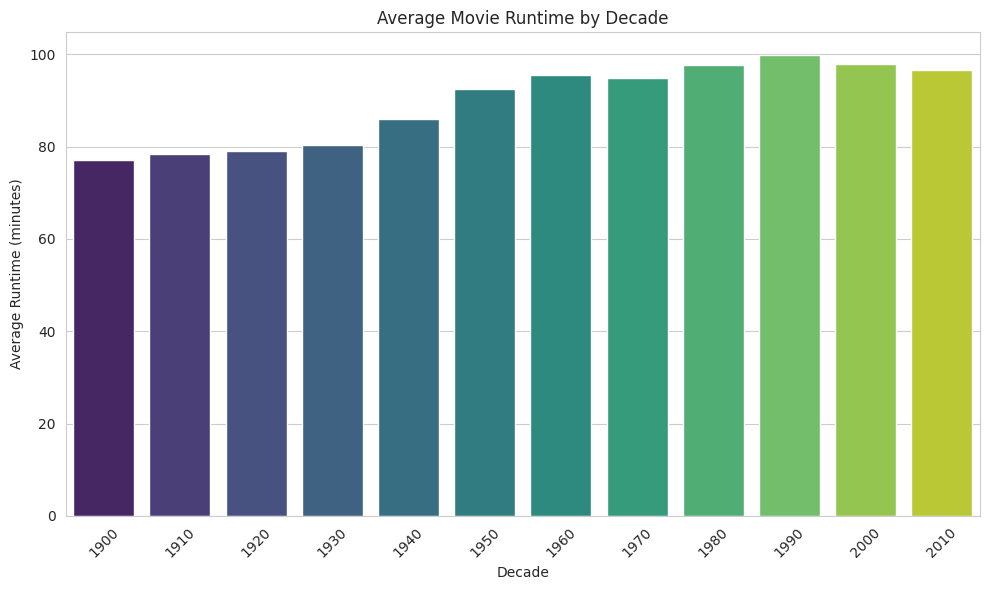

In [73]:
# Group by decade and calculate average runtime
runtime_by_decade = df_decade.groupby('decade')['runtimeMinutes'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=runtime_by_decade, x='decade', y='runtimeMinutes', palette='viridis')

plt.title('Average Movie Runtime by Decade')
plt.xlabel('Decade')
plt.ylabel('Average Runtime (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

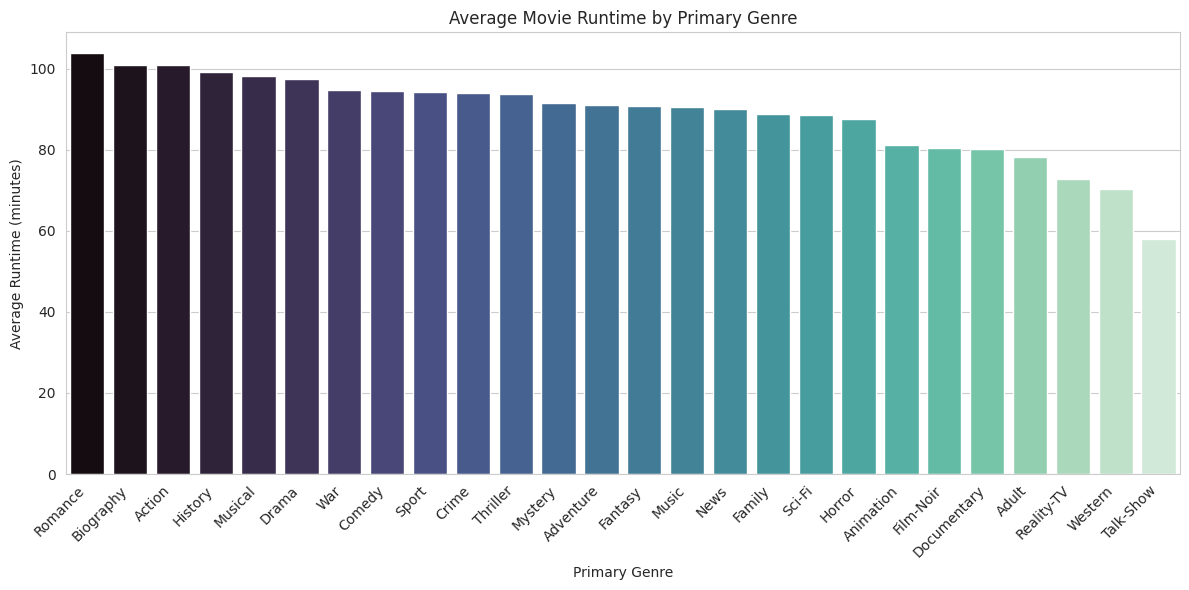

In [74]:
# Ensure runtime is numeric
df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')

# Drop rows with missing values in genre or runtime
df_genre_runtime = df.dropna(subset=['genre1', 'runtimeMinutes'])

# Group by primary genre and calculate average runtime
genre_runtime = (
    df_genre_runtime.groupby('genre1')['runtimeMinutes']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=genre_runtime, x='genre1', y='runtimeMinutes', palette='mako')

plt.title('Average Movie Runtime by Primary Genre')
plt.xlabel('Primary Genre')
plt.ylabel('Average Runtime (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

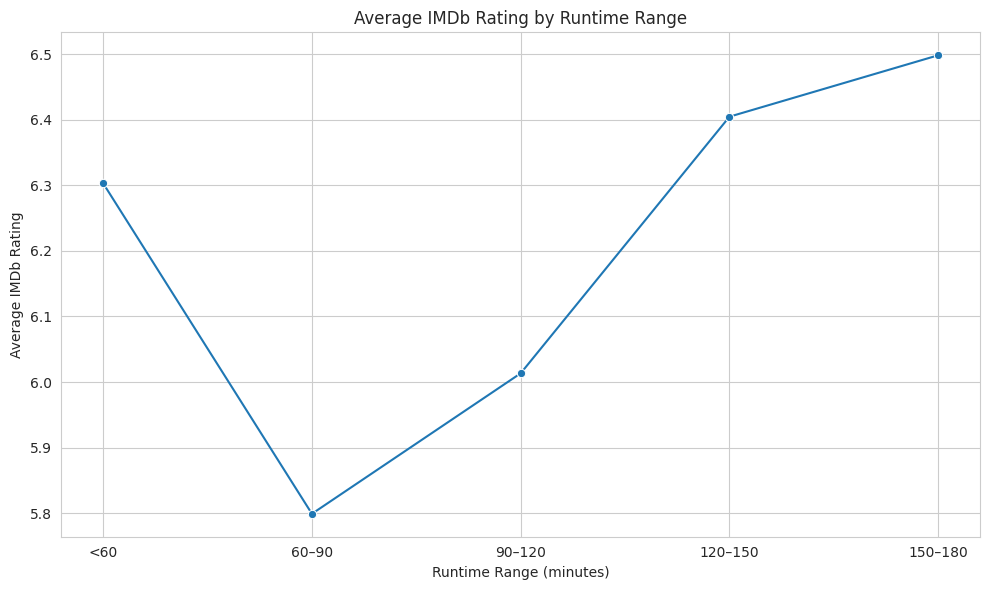

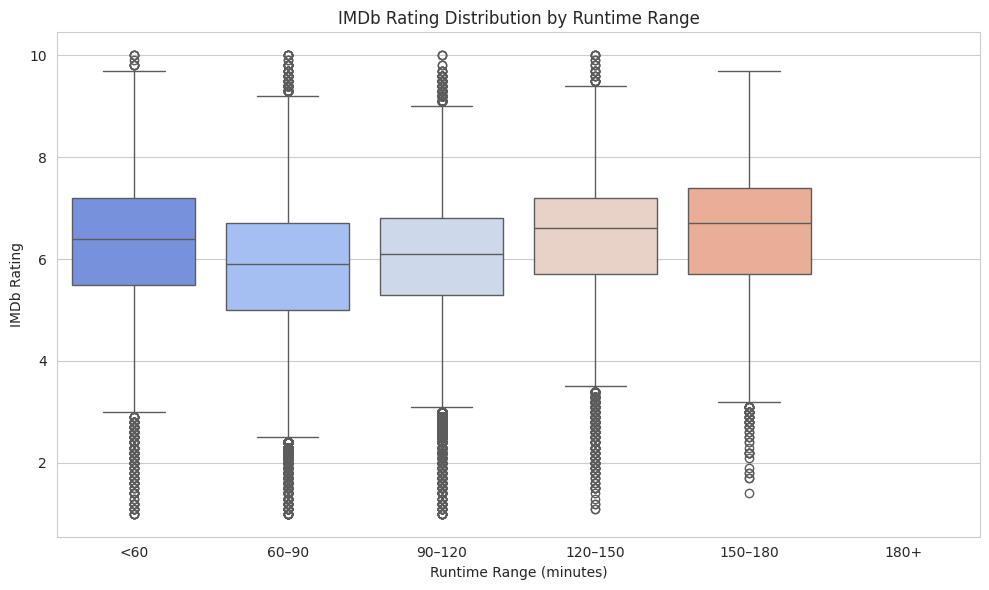

In [75]:
df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')

# Create bins and labels
df['runtime_bin'] = pd.cut(
    df['runtimeMinutes'],
    bins=[0, 60, 90, 120, 150, 180, 1000],
    labels=['<60', '60–90', '90–120', '120–150', '150–180', '180+']
)

runtime_rating = df.groupby('runtime_bin')['averageRating'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=runtime_rating, x='runtime_bin', y='averageRating', marker='o')
plt.title('Average IMDb Rating by Runtime Range')
plt.xlabel('Runtime Range (minutes)')
plt.ylabel('Average IMDb Rating')
plt.tight_layout()
plt.show()

print()
print()

df['runtime_bin'] = pd.cut(df['runtimeMinutes'], bins=[0, 60, 90, 120, 150, 180, 240],
                           labels=['<60', '60–90', '90–120', '120–150', '150–180', '180+'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='runtime_bin', y='averageRating', palette='coolwarm')
plt.title('IMDb Rating Distribution by Runtime Range')
plt.xlabel('Runtime Range (minutes)')
plt.ylabel('IMDb Rating')
plt.tight_layout()
plt.show()

IMDb Movie Average Rating Summary

Mean Rating             : 5.98
Standard Deviation      : 1.28
Minimum Rating          : 1.0  (31 movies)
Maximum Rating          : 10.0  (20 movies)




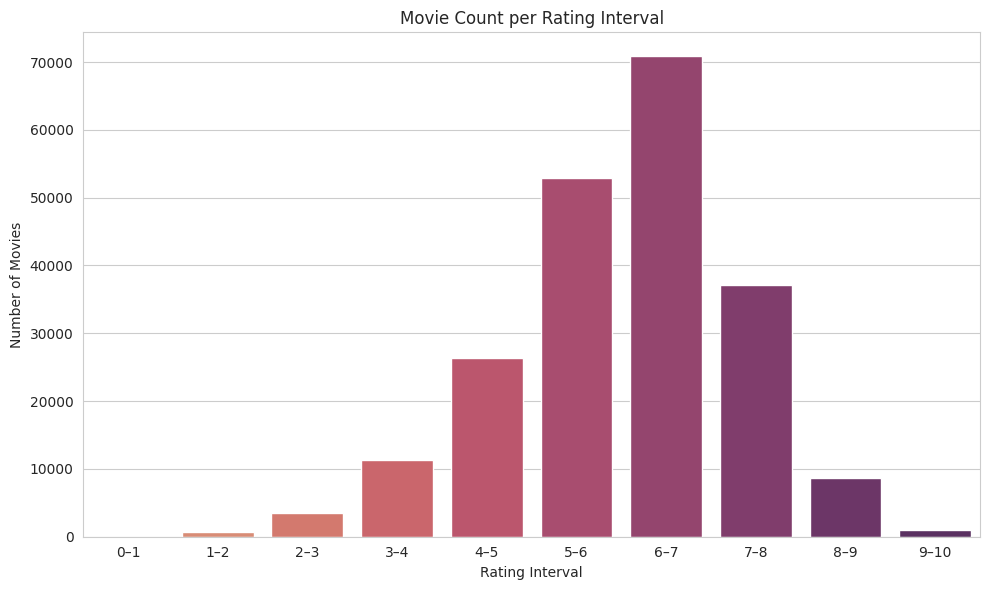

In [76]:
# Basic statistical summary
mean_rating = df['averageRating'].mean()
std_rating = df['averageRating'].std()
min_rating = df['averageRating'].min()
max_rating = df['averageRating'].max()

min_count = (df['averageRating'] == min_rating).sum()
max_count = (df['averageRating'] == max_rating).sum()

print("IMDb Movie Average Rating Summary\n")
print(f"Mean Rating             : {mean_rating:.2f}")
print(f"Standard Deviation      : {std_rating:.2f}")
print(f"Minimum Rating          : {min_rating:.1f}  ({min_count} movies)")
print(f"Maximum Rating          : {max_rating:.1f}  ({max_count} movies)\n")

print()

# Create bins
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
labels = ['0–1', '1–2', '2–3', '3–4', '4–5', '5–6', '6–7', '7–8', '8–9', '9–10']
df['rating_bin'] = pd.cut(df['averageRating'], bins=bins, labels=labels, right=False)

# Count number of movies in each bin
rating_dist = df['rating_bin'].value_counts().sort_index()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=rating_dist.index, y=rating_dist.values, palette='flare')
plt.title('Movie Count per Rating Interval')
plt.xlabel('Rating Interval')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

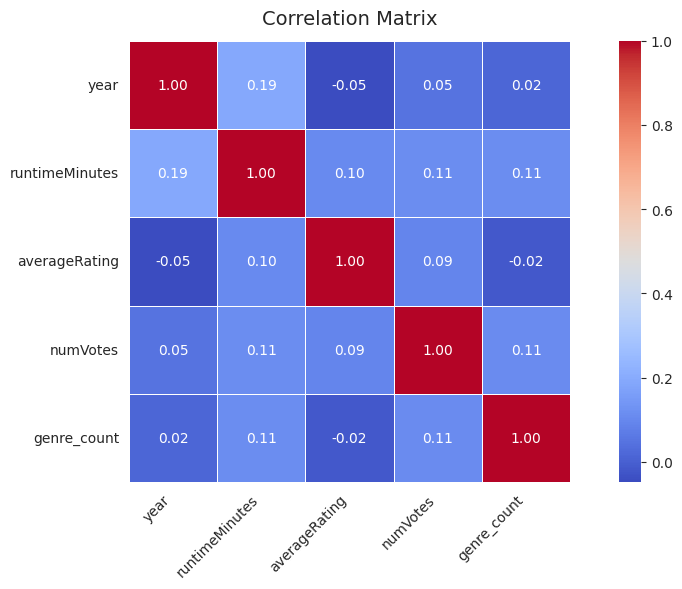

In [77]:
# Select numerical columns for correlation
numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['decade','startYear'], errors='ignore')
corr_matrix = numeric_cols.corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)

# Set titles and formatting
plt.title("Correlation Matrix", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

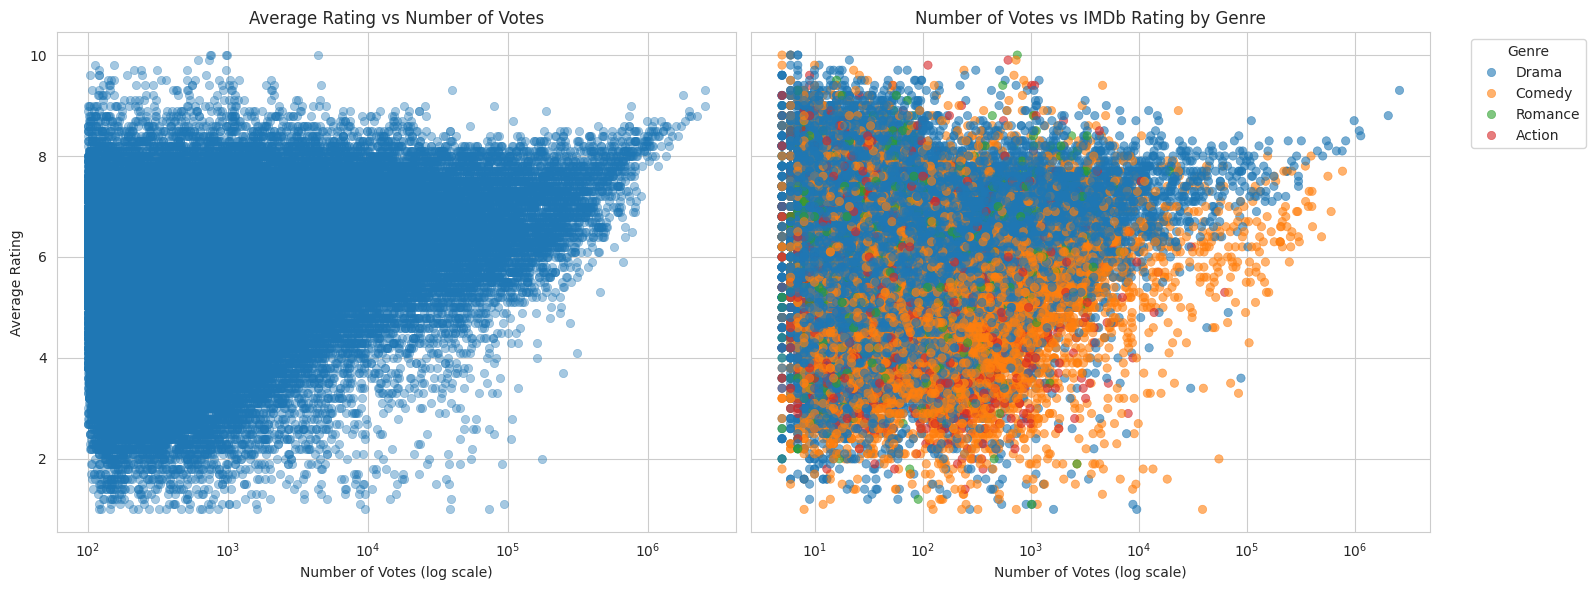

In [78]:
sns.set_style("whitegrid")

# Filter out movies with very few votes
filtered_df = df[df['numVotes'] >= 100]

# Explode 'genres' column for genre-based scatter plot
df_genre_votes_rating = df.explode('genres')
four_genres = ['Drama', 'Comedy', 'Action', 'Romance']
df_genre_votes_rating = df_genre_votes_rating[df_genre_votes_rating['genres'].isin(four_genres)]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Left plot : All movies (log-scaled Votes vs Rating)
sns.scatterplot(
    data=filtered_df,
    x='numVotes',
    y='averageRating',
    alpha=0.4,
    edgecolor=None,
    ax=axes[0]
)
axes[0].set_xscale('log')
axes[0].set_title('Average Rating vs Number of Votes')
axes[0].set_xlabel('Number of Votes (log scale)')
axes[0].set_ylabel('Average Rating')

# Right plot : Genre-wise colored scatter plot
sns.scatterplot(
    data=df_genre_votes_rating,
    x='numVotes',
    y='averageRating',
    hue='genres',
    palette='tab10',
    alpha=0.6,
    edgecolor=None,
    ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_title('Number of Votes vs IMDb Rating by Genre')
axes[1].set_xlabel('Number of Votes (log scale)')
axes[1].set_ylabel('')

# Move legend out of the plot
axes[1].legend(title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

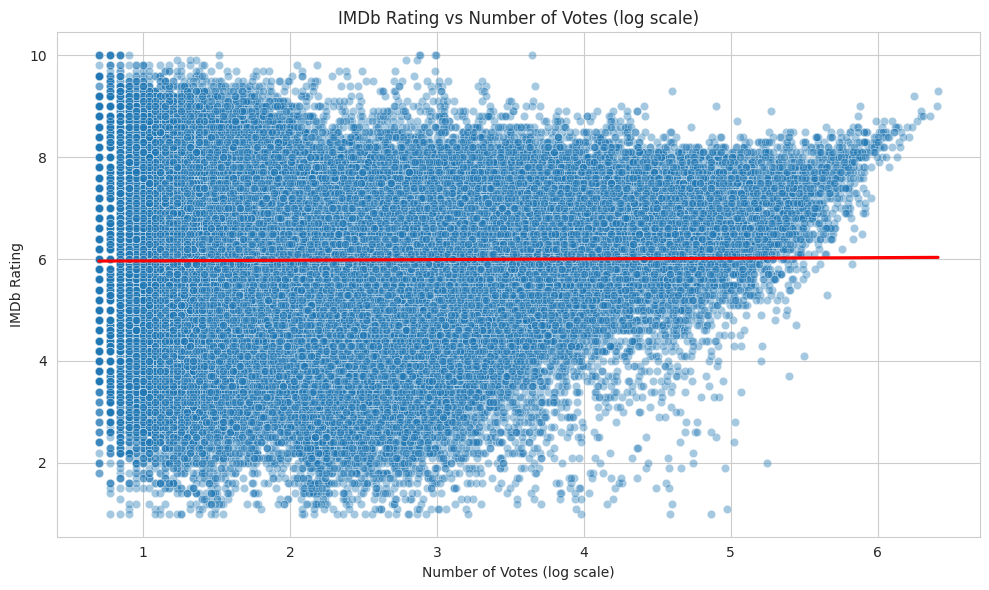

In [79]:
# Convert to numeric
df['numVotes'] = pd.to_numeric(df['numVotes'], errors='coerce')
df['averageRating'] = pd.to_numeric(df['averageRating'], errors='coerce')

# Filter out rows with missing or 0 votes
df_votes = df[df['numVotes'] > 0].copy()

# Log-transform votes for better spread
df_votes['logVotes'] = np.log10(df_votes['numVotes'])

# Scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_votes, x='logVotes', y='averageRating', alpha=0.4)
sns.regplot(data=df_votes, x='logVotes', y='averageRating', scatter=False, color='red')
plt.title('IMDb Rating vs Number of Votes (log scale)')
plt.xlabel('Number of Votes (log scale)')
plt.ylabel('IMDb Rating')
plt.tight_layout()
plt.show()

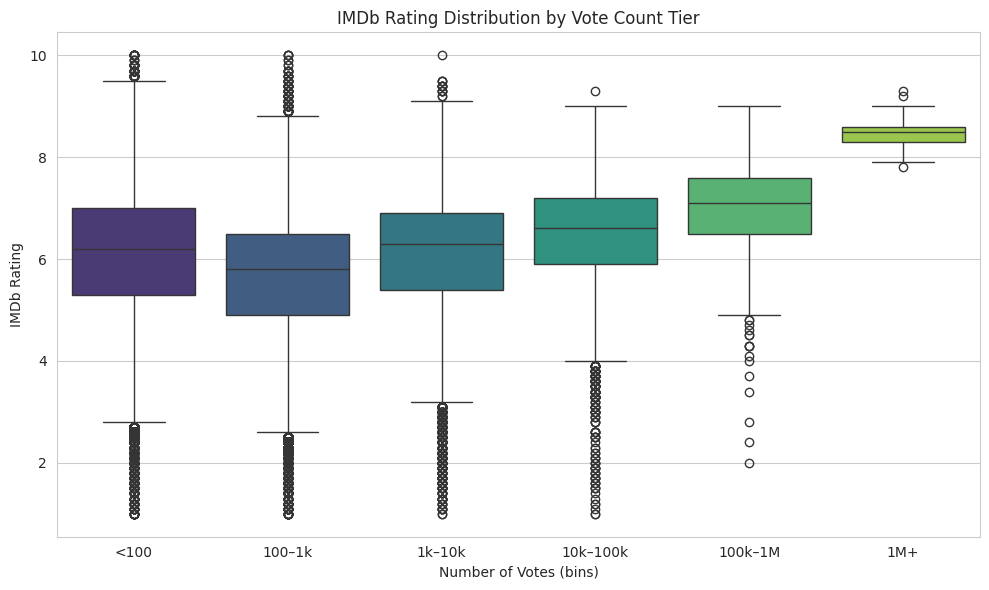

In [80]:
df_votes['vote_bin'] = pd.cut(
    df_votes['numVotes'],
    bins=[0, 100, 1000, 10000, 100000, 1000000, np.inf],
    labels=['<100', '100–1k', '1k–10k', '10k–100k', '100k–1M', '1M+']
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_votes, x='vote_bin', y='averageRating', palette='viridis')
plt.title('IMDb Rating Distribution by Vote Count Tier')
plt.xlabel('Number of Votes (bins)')
plt.ylabel('IMDb Rating')
plt.tight_layout()
plt.show()

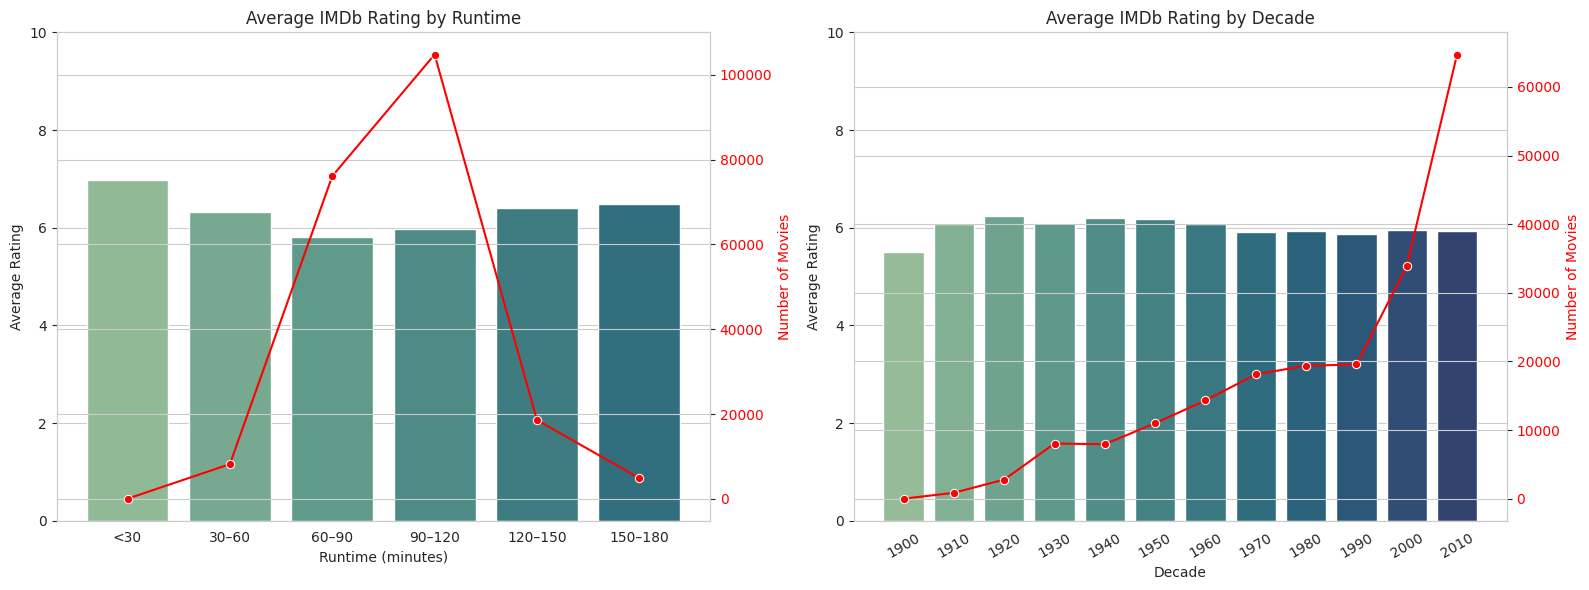

In [81]:
sns.set_style("whitegrid")

# Define runtime bins
max_runtime = max(241, df_filtered_runtime['runtimeMinutes'].max())
bins = [0, 30, 60, 90, 120, 150, 180, 210, 240, max_runtime + 1]
labels = ['<30', '30–60', '60–90', '90–120', '120–150', '150–180', '180–210', '210–240', '240+']

# Bin the runtime column
df_filtered_runtime['runtime_bin'] = pd.cut(
    df_filtered_runtime['runtimeMinutes'],
    bins=bins,
    labels=labels,
    right=False
)

# Group by runtime bin
runtime_stats = (
    df_filtered_runtime.groupby('runtime_bin')['averageRating']
    .agg(avg_rating='mean', movie_count='count')
    .reset_index()
    .dropna()
)

# Plot setup
df_decade_rating = df[df['decade'] < 2020]
decade_stats = (
    df_decade_rating
    .groupby('decade')['averageRating']
    .agg(avg_rating='mean', movie_count='count')
    .reset_index()
)
decade_stats['decade'] = decade_stats['decade'].astype(str)

# Side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Left plot : Average Rating vs Runtime
ax1 = axes[0]
sns.barplot(data=runtime_stats, x='runtime_bin', y='avg_rating', palette='crest', ax=ax1)
ax1.set_title("Average IMDb Rating by Runtime")
ax1.set_xlabel("Runtime (minutes)")
ax1.set_ylabel("Average Rating")
ax1.set_ylim(0, 10)

# Twin axis for movie count (runtime)
ax1b = ax1.twinx()
sns.lineplot(data=runtime_stats, x='runtime_bin', y='movie_count', color='red', marker='o', ax=ax1b)
ax1b.set_ylabel("Number of Movies", color='red')
ax1b.tick_params(axis='y', labelcolor='red')

# Right plot: Average Rating vs Decade
ax2 = axes[1]
sns.barplot(data=decade_stats, x='decade', y='avg_rating', palette='crest', ax=ax2)
ax2.set_title("Average IMDb Rating by Decade")
ax2.set_xlabel("Decade")
ax2.set_ylabel("Average Rating")
ax2.set_ylim(0, 10)
ax2.tick_params(axis='x', rotation=30)

# Twin axis for movie count (decade)
ax2b = ax2.twinx()
sns.lineplot(data=decade_stats, x='decade', y='movie_count', color='red', marker='o', ax=ax2b)
ax2b.set_ylabel("Number of Movies", color='red')
ax2b.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()

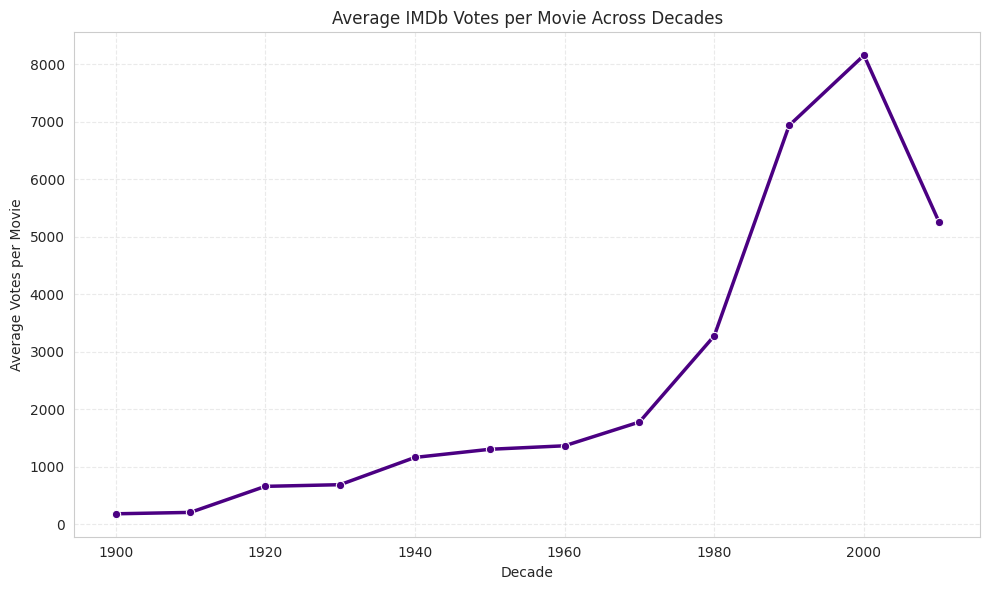

In [82]:
# Filter out decade 2020
df_decade = df[df['decade'] < 2020]

# Group by decade and calculate average number of votes
decade_avg_votes = (
    df_decade
    .groupby('decade')['numVotes']
    .mean()
    .reset_index(name='avg_votes')
)

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=decade_avg_votes, x='decade', y='avg_votes', marker='o', linewidth=2.5, color='indigo')

plt.title("Average IMDb Votes per Movie Across Decades")
plt.xlabel("Decade")
plt.ylabel("Average Votes per Movie")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

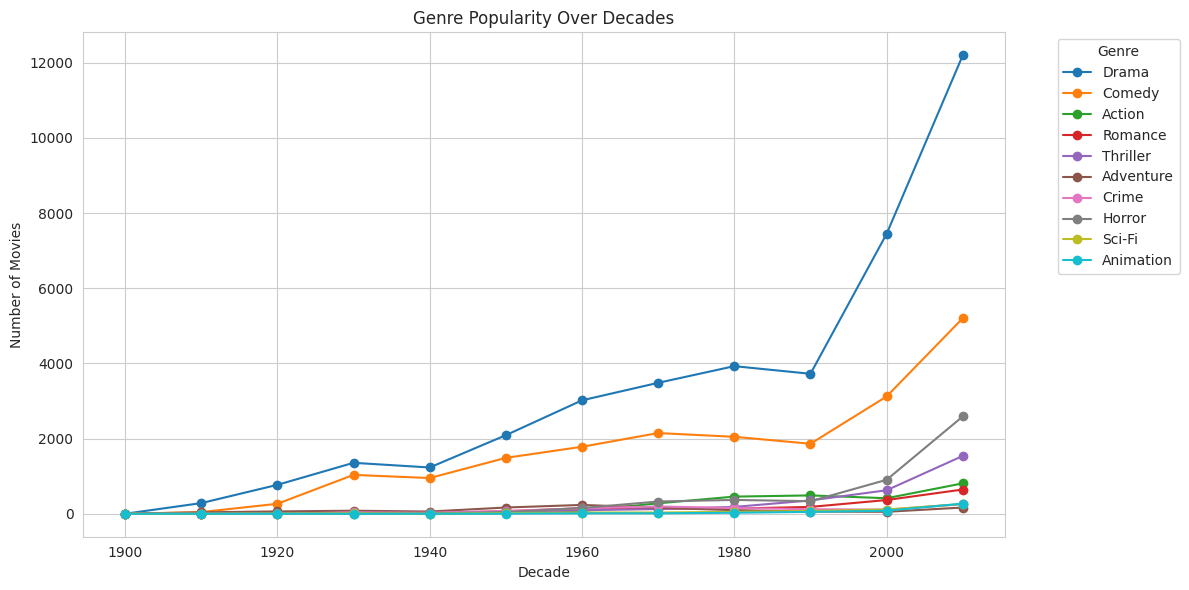

In [83]:
# Explode the 'genres' column to handle multiple genres per movie
genre_df = df.explode('genres')

# Exclude the 2020s
genre_df = genre_df[genre_df['decade'] < 2020]

# Define the 10 genres for consistent, relevant analysis
ten_genres = ['Drama', 'Comedy', 'Action', 'Romance', 'Thriller',
              'Adventure', 'Crime', 'Horror', 'Sci-Fi', 'Animation']

# Filter dataset to include only the selected genres
genre_df_top = genre_df[genre_df['genres'].isin(ten_genres)]

# Count number of movies for each genre in each decade
genre_counts = (
    genre_df_top
    .groupby(['decade', 'genres'])
    .size()
    .reset_index(name='count')
)

# Pivot the table to prepare for line plot
genre_pivot = genre_counts.pivot(index='decade', columns='genres', values='count').fillna(0)

# Plot line graph
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

for genre in ten_genres:
    plt.plot(genre_pivot.index, genre_pivot[genre], marker='o', label=genre)

plt.title("Genre Popularity Over Decades")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

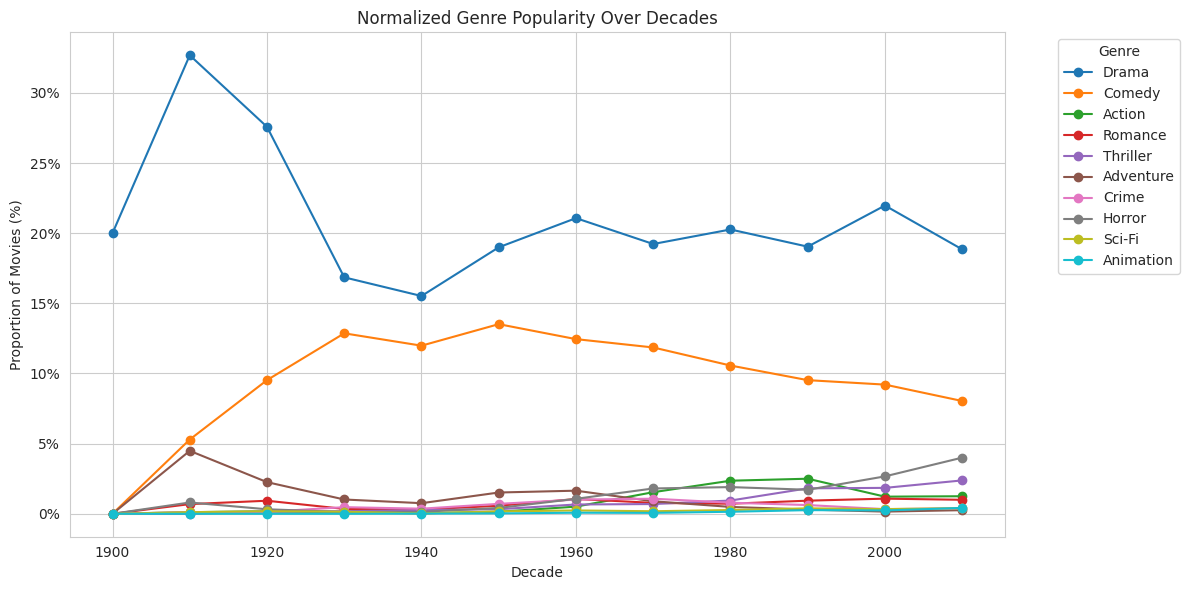

In [84]:
# Explode the 'genres' column to handle multiple genres per movie
genre_df = df.explode('genres')

# Exclude the 2020s
genre_df = genre_df[genre_df['decade'] < 2020]

# Define the 10 genres for consistent, relevant analysis
ten_genres = ['Drama', 'Comedy', 'Action', 'Romance', 'Thriller',
              'Adventure', 'Crime', 'Horror', 'Sci-Fi', 'Animation']

# Filter dataset to include only the selected genres
genre_df_top = genre_df[genre_df['genres'].isin(ten_genres)]

# Count number of movies for each genre in each decade
genre_counts = (
    genre_df_top
    .groupby(['decade', 'genres'])
    .size()
    .reset_index(name='count')
)

# Total number of movies per decade (after exploding)
total_per_decade = genre_df.groupby('decade').size().reset_index(name='total')

# Merge counts with totals
genre_counts = genre_counts.merge(total_per_decade, on='decade')

# Normalize : calculate proportion
genre_counts['normalized'] = genre_counts['count'] / genre_counts['total']

# Pivot for line plot
genre_pivot = genre_counts.pivot(index='decade', columns='genres', values='normalized').fillna(0)

# Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

for genre in ten_genres:
    plt.plot(genre_pivot.index, genre_pivot[genre], marker='o', label=genre)

plt.title("Normalized Genre Popularity Over Decades")
plt.xlabel("Decade")
plt.ylabel("Proportion of Movies (%)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

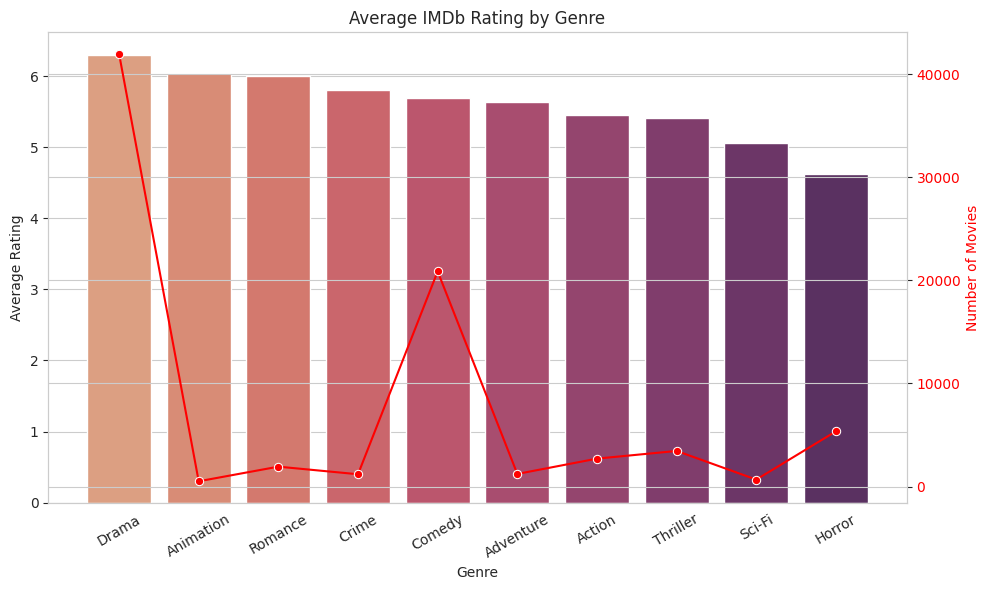

In [85]:
# Explode genres
df_genres = df.explode('genres')

# Define select 10 genres
ten_genres = ['Drama', 'Comedy', 'Action', 'Romance', 'Thriller',
              'Adventure', 'Crime', 'Horror', 'Sci-Fi', 'Animation']

# Filter the selected genres
df_genres = df_genres[df_genres['genres'].isin(ten_genres)]

# Group by genre and compute stats
genre_rating_stats = (
    df_genres
    .groupby('genres')['averageRating']
    .agg(avg_rating='mean', movie_count='count')
    .reset_index()
    .sort_values(by='avg_rating', ascending=False)
)

# Set category order for clean plotting
genre_rating_stats['genres'] = pd.Categorical(
    genre_rating_stats['genres'],
    categories=genre_rating_stats['genres'],
    ordered=True
)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=genre_rating_stats, x='genres', y='avg_rating', palette='flare')
# Overlay movie count as red line
ax2 = ax.twinx()
sns.lineplot(data=genre_rating_stats, x='genres', y='movie_count', color='red', marker='o', ax=ax2)
ax2.set_ylabel("Number of Movies", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Set labels and title
ax.set_title("Average IMDb Rating by Genre")
ax.set_xlabel("Genre")
ax.set_ylabel("Average Rating")
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

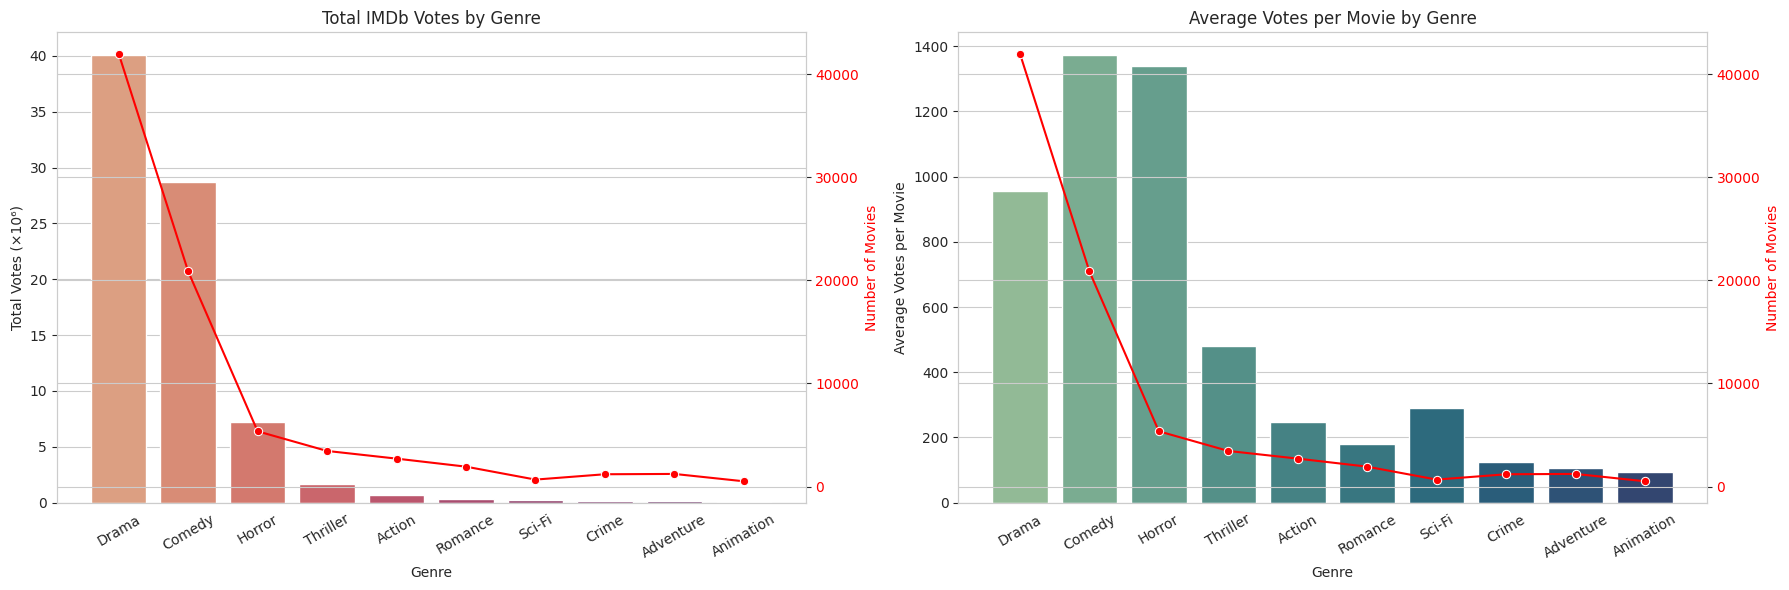

In [86]:
import matplotlib.ticker as ticker

# Explode the 'genres' column
df_genres = df.explode('genres')

# Define the 10 genres
ten_genres = ['Drama', 'Comedy', 'Action', 'Romance', 'Thriller',
              'Adventure', 'Crime', 'Horror', 'Sci-Fi', 'Animation']

# Filter only the selected genres
df_genres = df_genres[df_genres['genres'].isin(ten_genres)]

# Compute stats
genre_stats = (
    df_genres
    .groupby('genres')['numVotes']
    .agg(total_votes='sum', avg_votes='mean', movie_count='count')
    .reset_index()
    .sort_values(by='total_votes', ascending=False)
)

# Sort genres for consistent x-axis
genre_stats['genres'] = pd.Categorical(genre_stats['genres'],
                                       categories=genre_stats['genres'], ordered=True)

# Plot setup
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.set_style("whitegrid")

# Plot 1 : Total Votes
ax1 = axes[0]
sns.barplot(data=genre_stats, x='genres', y='total_votes', palette='flare', ax=ax1)
ax1.set_title("Total IMDb Votes by Genre")
ax1.set_xlabel("Genre")
ax1.set_ylabel("Total Votes (×10⁶)")
ax1.tick_params(axis='x', rotation=30)

# Format y-axis ticks to millions
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x / 1e6:.0f}'))

# Line plot for number of movies
ax1b = ax1.twinx()
sns.lineplot(data=genre_stats, x='genres', y='movie_count', color='red', marker='o', ax=ax1b)
ax1b.set_ylabel("Number of Movies", color='red')
ax1b.tick_params(axis='y', labelcolor='red')


# Plot 2 : Average Votes
ax2 = axes[1]
sns.barplot(data=genre_stats, x='genres', y='avg_votes', palette='crest', ax=ax2)
ax2.set_title("Average Votes per Movie by Genre")
ax2.set_xlabel("Genre")
ax2.set_ylabel("Average Votes per Movie")
ax2.tick_params(axis='x', rotation=30)

# Line plot for number of movies
ax2b = ax2.twinx()
sns.lineplot(data=genre_stats, x='genres', y='movie_count', color='red', marker='o', ax=ax2b)
ax2b.set_ylabel("Number of Movies", color='red')
ax2b.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()

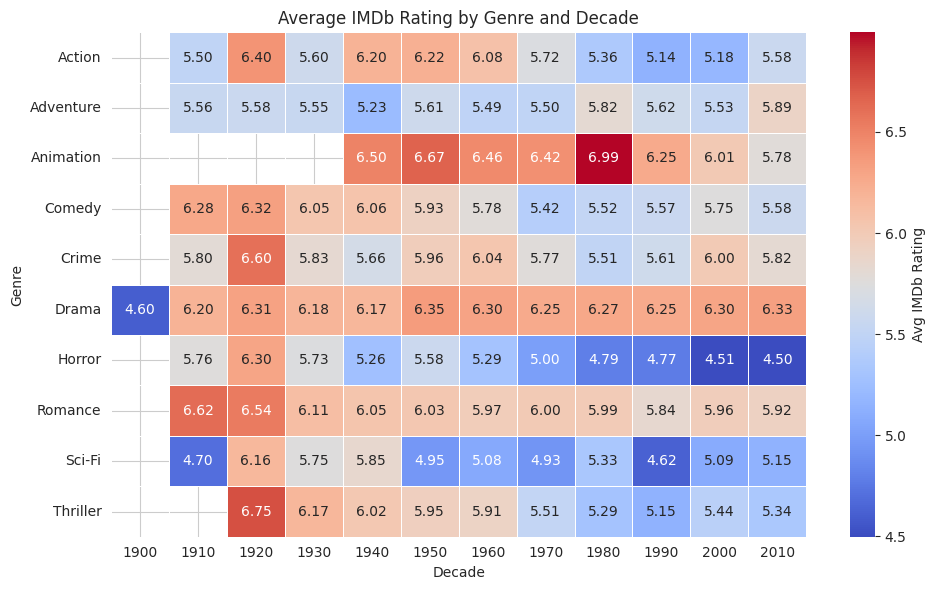

In [87]:
# Define the 10 most relevant genres
ten_genres = ['Drama', 'Comedy', 'Action', 'Romance', 'Thriller',
              'Adventure', 'Crime', 'Horror', 'Sci-Fi', 'Animation']

# Explode the 'genres' column to have one genre per row
genre_df = df.explode('genres')

# Filter for the selected 10 genres only
genre_df = genre_df[genre_df['genres'].isin(ten_genres)]

# Remove 2020s and ensure no null genres
genre_df = genre_df[genre_df['decade'] < 2020]

# Group by genre and decade, and compute mean rating
genre_decade_rating = (
    genre_df
    .groupby(['genres', 'decade'])['averageRating']
    .mean()
    .reset_index()
)

# Pivot the table for heatmap
heatmap_data = genre_decade_rating.pivot(index='genres', columns='decade', values='averageRating')

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, cbar_kws={'label': 'Avg IMDb Rating'})
plt.title("Average IMDb Rating by Genre and Decade")
plt.xlabel("Decade")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

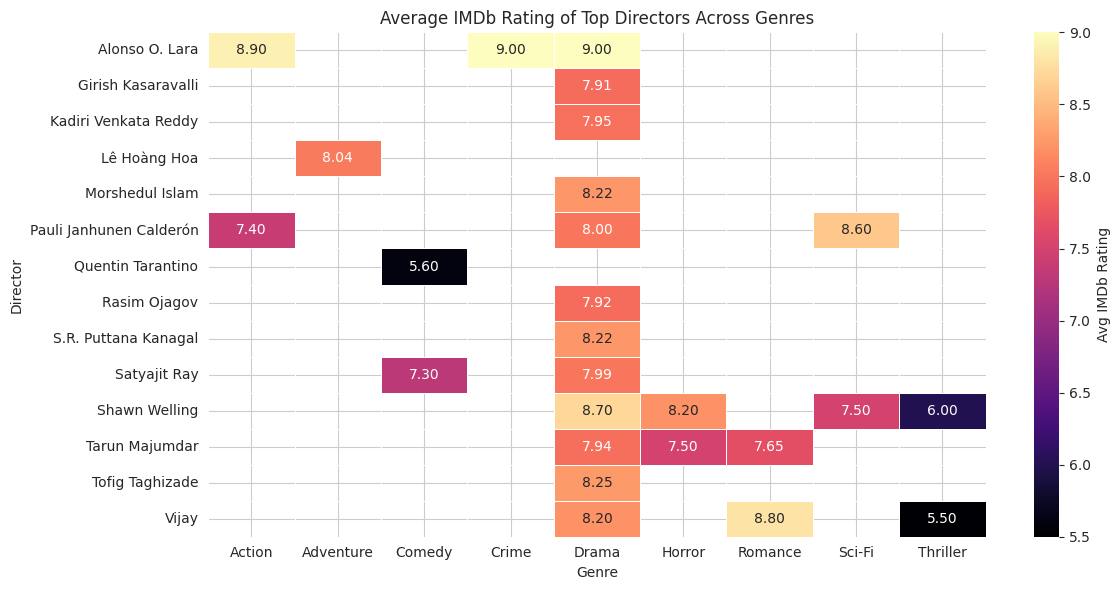

In [88]:
# Define the top 10 genres to include in the analysis
ten_genres = ['Drama', 'Comedy', 'Action', 'Romance', 'Thriller',
              'Adventure', 'Crime', 'Horror', 'Sci-Fi', 'Animation']

# Retrieve the list of top directors by average rating
top_directors_list = top_directors_by_rating['Director'].tolist()

# Explode the 'genres' and 'directorName' columns to handle multiple entries
df_top_directors = df.explode('genres').explode('directorName')

# Filter the DataFrame to include only selected genres and top directors
df_top_directors = df_top_directors[
    df_top_directors['genres'].isin(ten_genres) &
    df_top_directors['directorName'].isin(top_directors_list)
]

# Group by director and genre to calculate average IMDb rating
director_genre_rating = (
    df_top_directors
    .groupby(['directorName', 'genres'])['averageRating']
    .mean()
    .reset_index()
)

# Pivot the DataFrame to create a matrix of directors vs. genres
heatmap_df = director_genre_rating.pivot(index='directorName', columns='genres', values='averageRating')

# Generate Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="magma", linewidths=0.5, cbar_kws={'label': 'Avg IMDb Rating'})
plt.title("Average IMDb Rating of Top Directors Across Genres")
plt.xlabel("Genre")
plt.ylabel("Director")
plt.tight_layout()
plt.show()

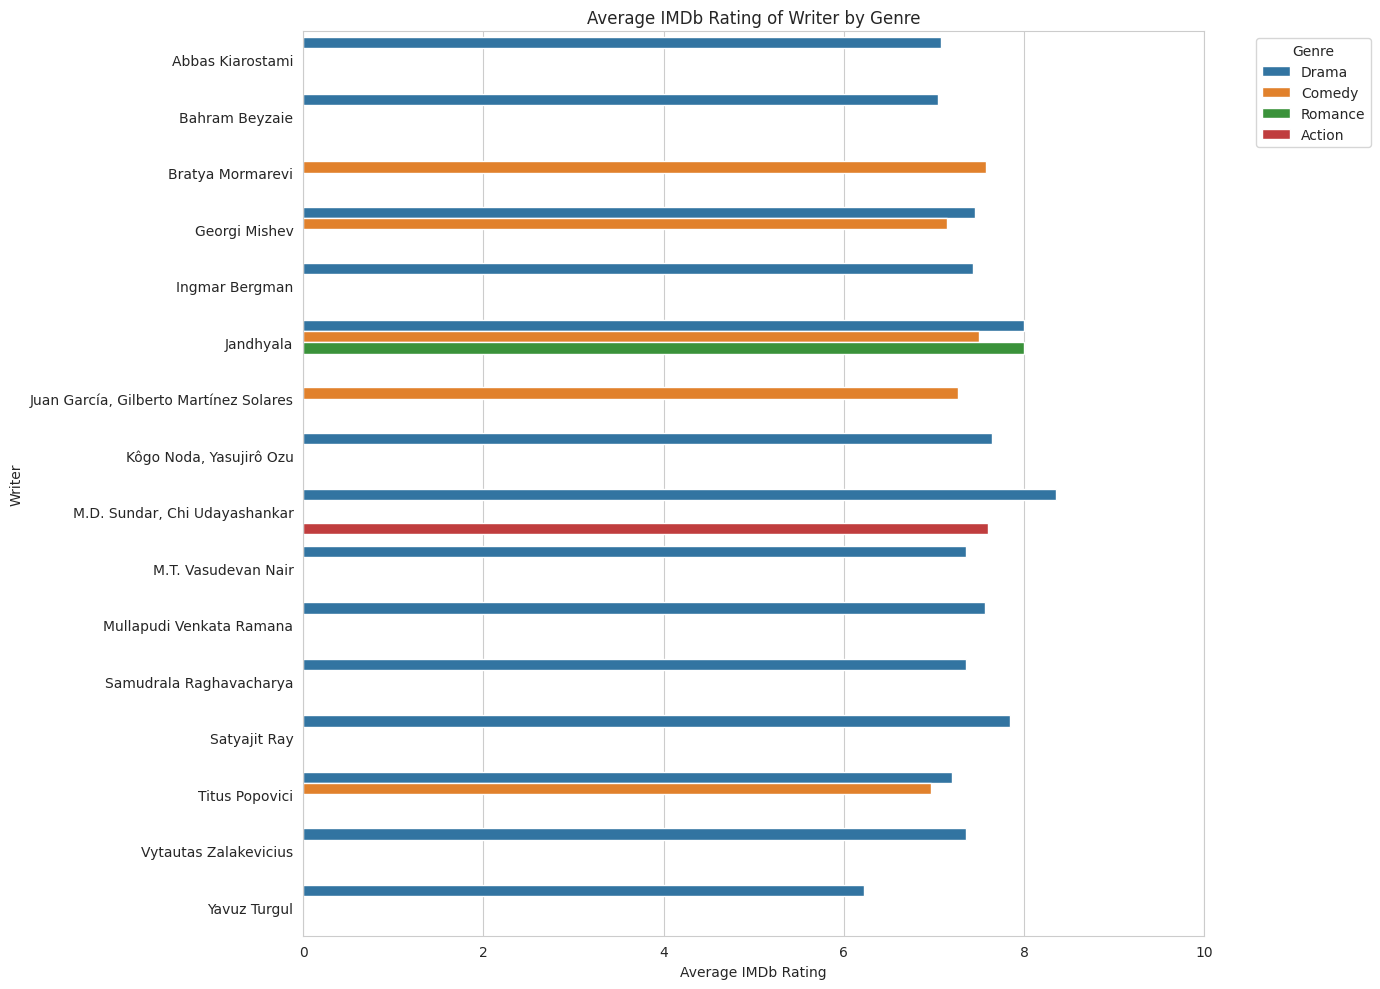

In [89]:
# Define the genres to include in the analysis
ten_genres = ['Drama', 'Comedy', 'Action', 'Romance']

# Retrieve the list of all top writers from the final_writer_table
top_writers_list = final_writer_table['Writer'].tolist()

# Explode 'writerNames' and 'genres' columns to handle multiple entries
df_writer_genre = df.explode('writerNames').explode('genres')

# Filter to include only top writers and selected genres
df_writer_genre = df_writer_genre[
    (df_writer_genre['writerNames'].isin(top_writers_list)) &
    (df_writer_genre['genres'].isin(ten_genres))
]

# Group by writer and genre to compute average IMDb rating
writer_genre_ratings = (
    df_writer_genre
    .groupby(['writerNames', 'genres'])['averageRating']
    .mean()
    .reset_index()
)

# Plot grouped bar plot
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")
sns.barplot(data=writer_genre_ratings, y='writerNames', x='averageRating', hue='genres', palette='tab10')

plt.title("Average IMDb Rating of Writer by Genre")
plt.ylabel("Writer")
plt.xlabel("Average IMDb Rating")
plt.xlim(0, 10)
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

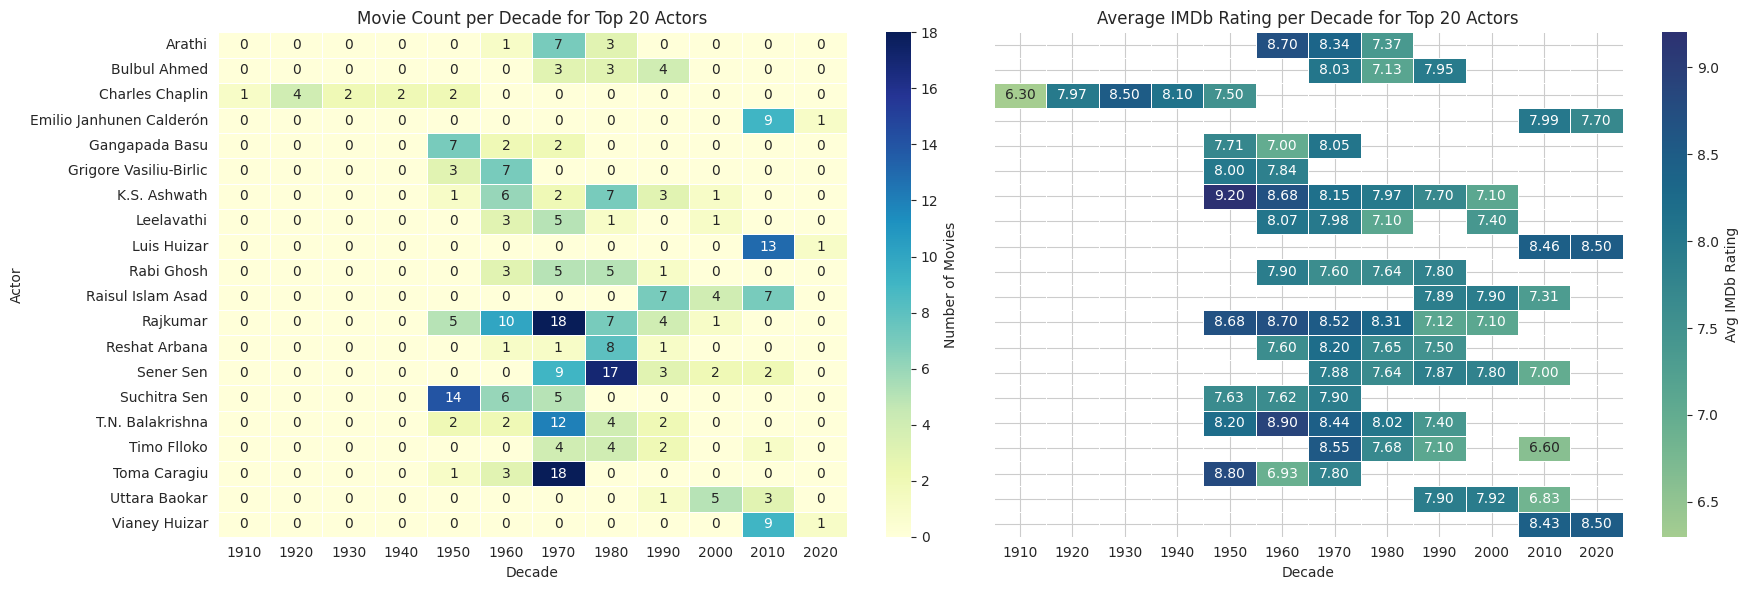

In [90]:
# Retrieve the list of top 20 actors
top_20_actors_list = final_actor_table['Actor'].tolist()

# Explode the 'actorNames' column to separate multiple actors per movie
df_actor = df.explode('actorNames')

# Filter the DataFrame to include only the top 20 actors
df_actor = df_actor[df_actor['actorNames'].isin(top_20_actors_list)]

# Group by actor and decade to compute number of movies
actor_decade_counts = (
    df_actor
    .groupby(['actorNames', 'decade'])
    .size()
    .reset_index(name='Movie Count')
)

# Pivot for movie count heatmap
actor_count_pivot = actor_decade_counts.pivot(index='actorNames', columns='decade', values='Movie Count').fillna(0)

# Group by actor and decade to compute average IMDb rating
actor_rating_by_decade = (
    df_actor
    .groupby(['actorNames', 'decade'])['averageRating']
    .mean()
    .reset_index()
)

# Pivot for average rating heatmap
actor_rating_pivot = actor_rating_by_decade.pivot(index='actorNames', columns='decade', values='averageRating')

# Create side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Heatmap 1 : Movie Count
sns.heatmap(actor_count_pivot, annot=True, fmt='.0f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Number of Movies'}, ax=axes[0])
axes[0].set_title("Movie Count per Decade for Top 20 Actors")
axes[0].set_xlabel("Decade")
axes[0].set_ylabel("Actor")

# Heatmap 2 : Average Rating
sns.heatmap(actor_rating_pivot, annot=True, fmt=".2f", cmap="crest",
            linewidths=0.5, cbar_kws={'label': 'Avg IMDb Rating'}, ax=axes[1])
axes[1].set_title("Average IMDb Rating per Decade for Top 20 Actors")
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()